## **FINAL PROJECT PCD: EXPERIMENT 3 (P3 - EDGE DETECTION PIPELINE)**

#### **Import Libraries**

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#### **Library Analysis**
* **os**: Used to interact with the operating system to read dataset paths.
* **cv2**: OpenCV library used to read, resize, and perform edge detection operations on images.
* **matplotlib / seaborn**: Libraries for visualization of dataset distribution, classification results, and feature correlation heatmap.
* **numpy / pandas**: Libraries for numerical computations, array manipulations, and tabular data management.
* **skimage / scipy**: Used for GLCM texture feature extraction and entropy calculation.
* **sklearn**: Machine learning framework for dataset splitting, classification model training (RF, SVM, KNN), and performance evaluation.

#### **Load Dataset**

In [ ]:
data = []
labels = []
file_name = []

dataset_path = "Dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)

#### **Dataset Loading Explanation**
* Reads the images and folders programmatically from the `Dataset/` directory.
* Filters directories and loads images using OpenCV's `imread`.
* Converts loaded images and folder classes/labels to NumPy arrays.

#### **P3 Preprocessing Pipeline (Resize -> Grayscale -> Gaussian Blur -> Canny Edge Detection -> Thresholding)**

In [ ]:
def p3_preprocessing(img):
    # 1. Resize
    resized = cv.resize(img, (256, 256))
    
    # 2. Grayscale
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
        
    # 3. Gaussian Blur
    smoothed = cv.GaussianBlur(gray, (5, 5), 0)
    
    # 4. Canny Edge Detection
    edges = cv.Canny(smoothed, 100, 200)
    
    # 5. Binary Thresholding
    _, thresh = cv.threshold(edges, 127, 255, cv.THRESH_BINARY)
    return thresh

# Apply P3 preprocessing pipeline to all data
dataPreprocessed = [p3_preprocessing(img) for img in data]

#### **P3 Preprocessing Explanation**
* **Resize**: Downsamples the image to a standardized size of 256x256 pixels.
* **Grayscale**: Converts color channels to single luminance channel.
* **Gaussian Blur**: Reduces image high-frequency noise.
* **Canny Edge Detection**: Extracts structural edge map using hysteresis thresholding.
* **Binary Thresholding**: Ensures strict 0 and 255 binary output image before texture calculation.

#### **Analyze and Visualize Data Distribution**

Image distribution per class:
        Class  Count
  Anthracnose     74
bird eye spot     74
      healthy     74


C:\Users\NITRO 5\AppData\Local\Temp\ipykernel_12792\3041207117.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dist, x='Class', y='Count', palette='viridis')


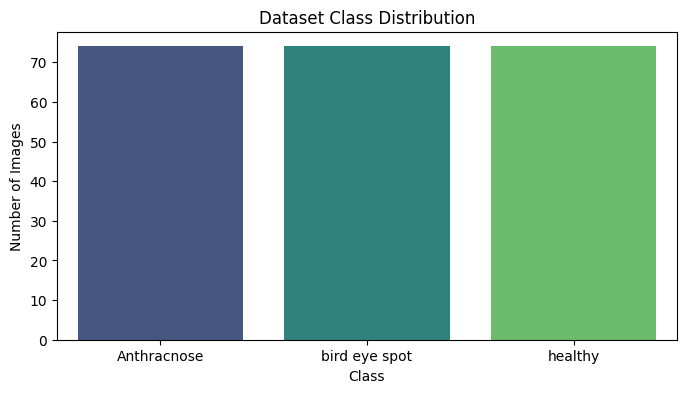

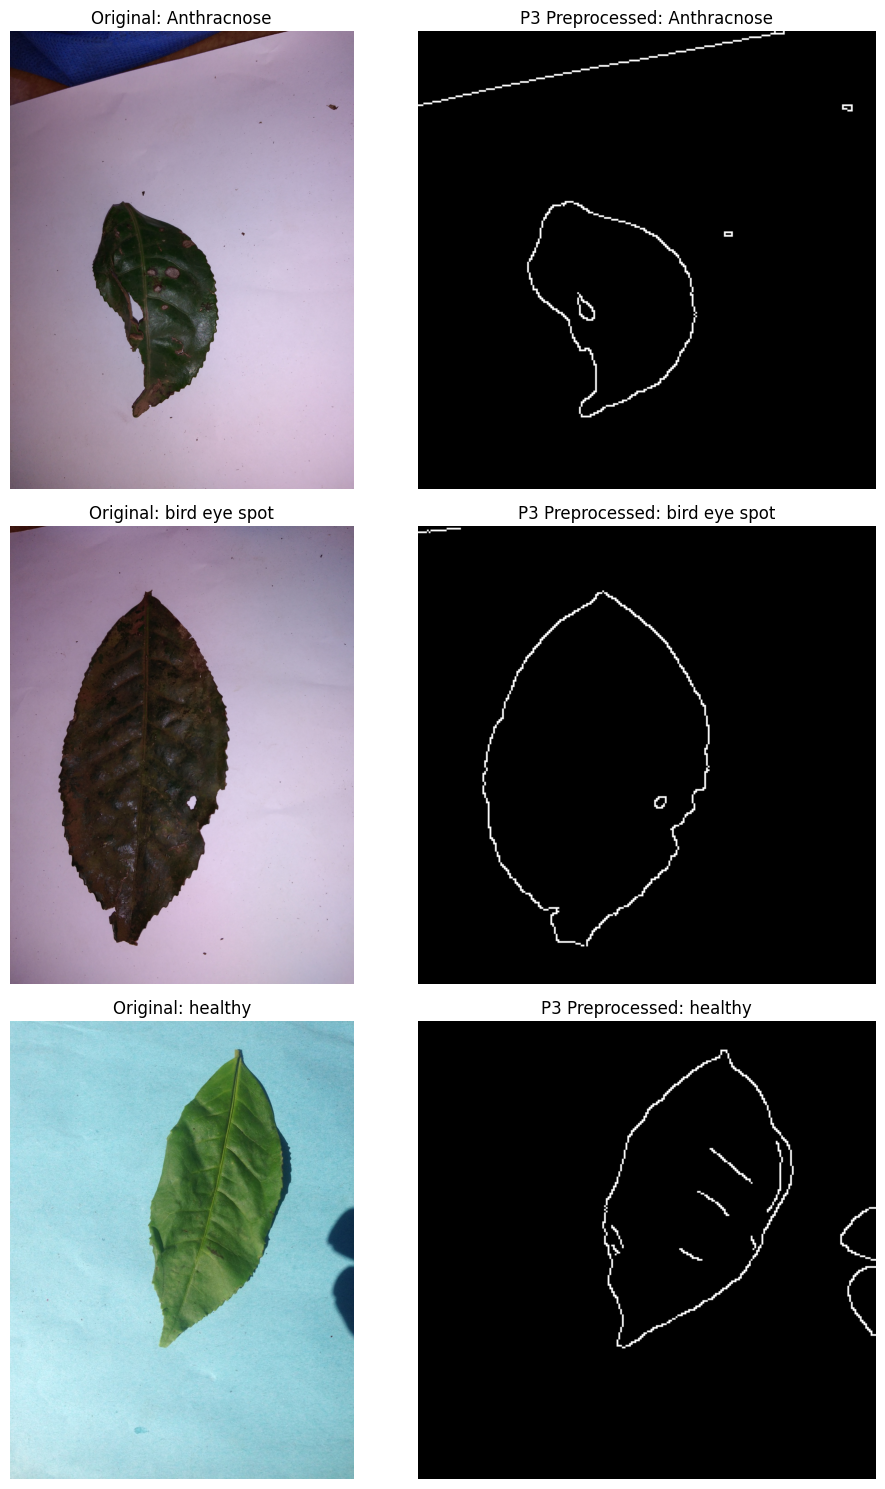

In [ ]:
# Class distribution
unique_labels, count_labels = np.unique(labels, return_counts=True)
df_dist = pd.DataFrame({'Class': unique_labels, 'Count': count_labels})
print("Image distribution per class:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=df_dist, x='Class', y='Count', palette='viridis')
plt.title('Dataset Class Distribution')
plt.ylabel('Number of Images')
plt.show()

# Show sample of original and preprocessed image from each class
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for idx, cls in enumerate(unique_labels):
    class_indices = np.where(labels == cls)[0]
    sample_idx = class_indices[0]
    orig = cv.cvtColor(data[sample_idx], cv.COLOR_BGR2RGB)
    prep = dataPreprocessed[sample_idx]
    
    axes[idx, 0].imshow(orig)
    axes[idx, 0].set_title(f'Original: {cls}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(prep, cmap='gray')
    axes[idx, 1].set_title(f'P3 Preprocessed: {cls}')
    axes[idx, 1].axis('off')
plt.tight_layout()
plt.show()

#### **GLCM Texture Feature Extraction**

In [ ]:
glcm_features = []
distances = [1]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

for img in dataPreprocessed:
    # Calculate GLCM matrix
    glcm = graycomatrix(img, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    
    # Extract properties
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()
    
    # Calculate entropy
    ent_vals = []
    for angle_idx in range(len(angles)):
        ent_vals.append(entropy(glcm[:, :, 0, angle_idx].ravel(), base=2))
    
    # Flatten features into one array
    features = np.hstack([contrast, dissimilarity, homogeneity, energy, correlation, ent_vals])
    glcm_features.append(features)

# Create column names
cols = []
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'entropy']
for prop in props:
    for angle in ['0', '45', '90', '135']:
        cols.append(f"{prop}_{angle}")

df_features = pd.DataFrame(glcm_features, columns=cols)
df_features['label'] = labels
print(df_features.head())

   contrast_0  contrast_45  contrast_90  contrast_135  dissimilarity_0  \
0  644.472656       1067.0   898.476562        1051.0         2.527344   
1  498.046875        682.0   555.820312         706.0         1.953125   
2  790.898438        834.0   557.812500         892.0         3.101562   
3  644.472656        859.0   639.492188         887.0         2.527344   
4  708.222656       1149.0   936.328125        1109.0         2.777344   

   dissimilarity_45  dissimilarity_90  dissimilarity_135  homogeneity_0  \
0          4.184314          3.523437           4.121569       0.990089   
1          2.674510          2.179688           2.768627       0.992341   
2          3.270588          2.187500           3.498039       0.987837   
3          3.368627          2.507813           3.478431       0.990089   
4          4.505882          3.671875           4.349020       0.989109   

   homogeneity_45  ...  energy_135  correlation_0  correlation_45  \
0        0.983591  ...    0.981369 

#### **Correlation-based Feature Selection**

Dropped 16 redundant features out of 24
Remaining features: 8


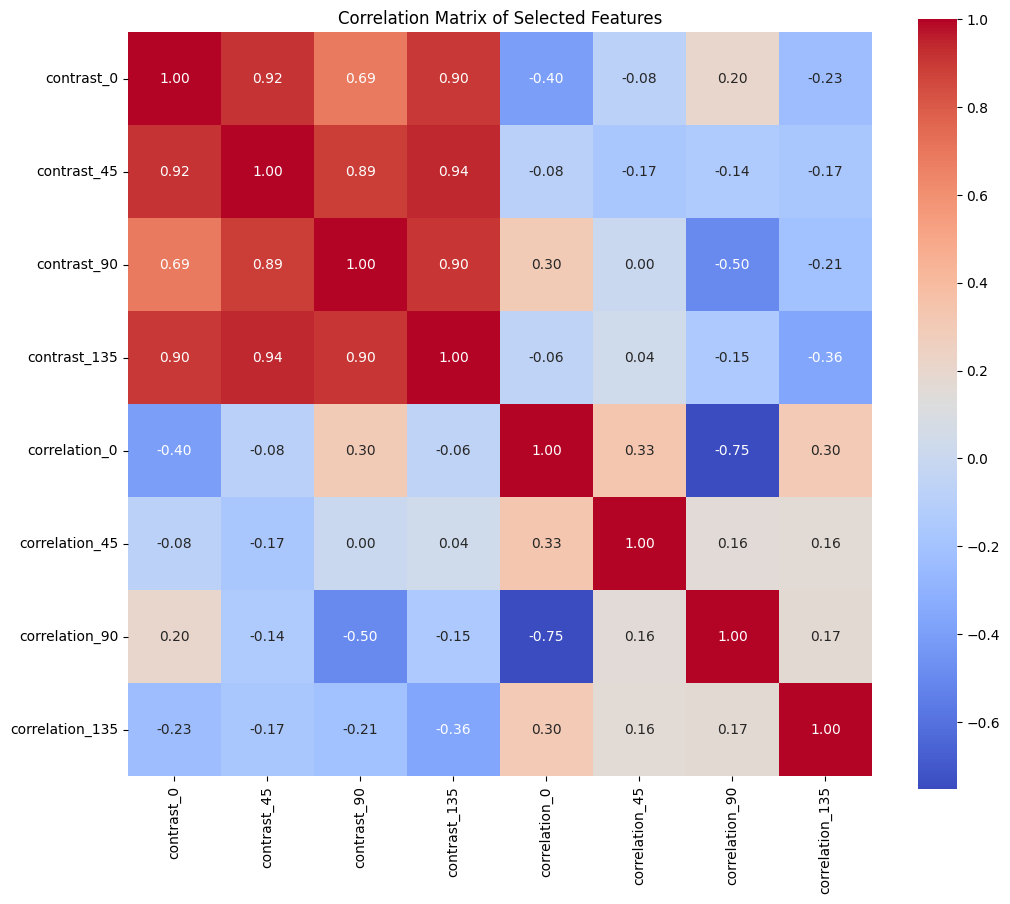

In [ ]:
x = df_features.drop(columns=['label'])
y = df_features['label']

correlation_matrix = x.corr()
threshold = 0.95
columns_to_drop = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            colname = correlation_matrix.columns[i]
            columns_to_drop.add(colname)

x_new = x.drop(columns=list(columns_to_drop))
print(f"Dropped {len(columns_to_drop)} redundant features out of {x.shape[1]}")
print(f"Remaining features: {x_new.shape[1]}")

# Plot Heatmap of remaining features
plt.figure(figsize=(12, 10))
sns.heatmap(x_new.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Selected Features')
plt.show()

#### **Model Training & Performance Evaluation**

=== Random Forest Performance ===
Accuracy  : 0.5333
Precision : 0.5506
Recall    : 0.5333
F1 Score  : 0.5378

Classification Report:
               precision    recall  f1-score   support

  Anthracnose       0.38      0.33      0.36        15
bird eye spot       0.42      0.53      0.47        15
      healthy       0.85      0.73      0.79        15

     accuracy                           0.53        45
    macro avg       0.55      0.53      0.54        45
 weighted avg       0.55      0.53      0.54        45



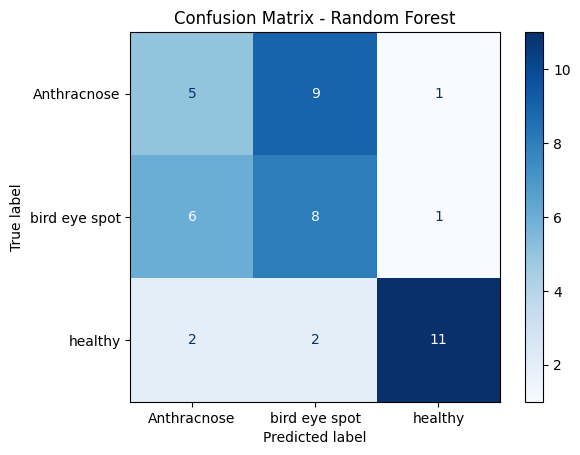

=== SVM Performance ===
Accuracy  : 0.4444
Precision : 0.4425
Recall    : 0.4444
F1 Score  : 0.4432

Classification Report:
               precision    recall  f1-score   support

  Anthracnose       0.29      0.27      0.28        15
bird eye spot       0.38      0.40      0.39        15
      healthy       0.67      0.67      0.67        15

     accuracy                           0.44        45
    macro avg       0.44      0.44      0.44        45
 weighted avg       0.44      0.44      0.44        45



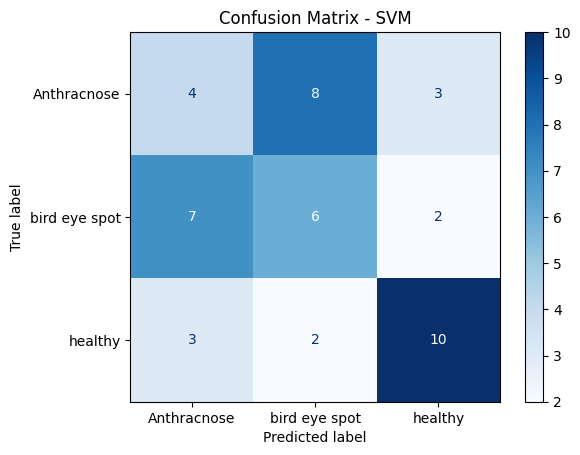

=== KNN Performance ===
Accuracy  : 0.7111
Precision : 0.7184
Recall    : 0.7111
F1 Score  : 0.7115

Classification Report:
               precision    recall  f1-score   support

  Anthracnose       0.61      0.73      0.67        15
bird eye spot       0.62      0.53      0.57        15
      healthy       0.93      0.87      0.90        15

     accuracy                           0.71        45
    macro avg       0.72      0.71      0.71        45
 weighted avg       0.72      0.71      0.71        45



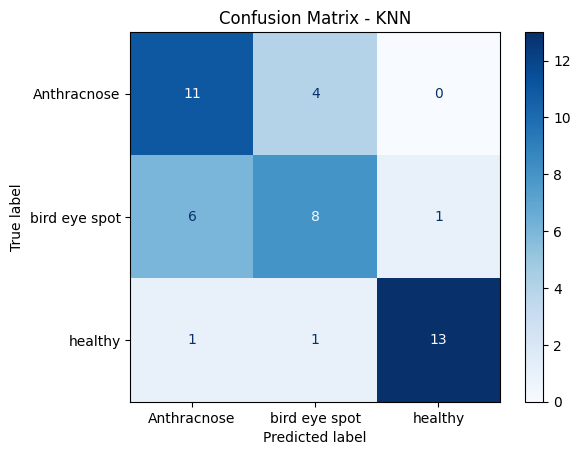

In [ ]:
# Split dataset
x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=3)
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"=== {name} Performance ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()